<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/code/Key_Authors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Load Data

In [ ]:
import pickle
import re
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfTransformer
import pprint
from tabulate import tabulate

In [ ]:
# Connect to Goole Drive to use the data.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Data
output_dir = "/content/drive/Shareddrives/KeyBoostAuthor/data/"
# output_dir = "/dt/puzis/cnalab/KeyAuthors/"

with open(output_dir + '/israel_and_the_region.pkl', 'rb') as f:
    df = pickle.load(f)

# Print df
df.head()

,c_claim_id,c_post_id,url,author,content,date,title,description,url_right,verdict_date,keywords,domain,verdict,category,sub_category
0,007677fd-d100-3f20-936e-3dea041cfb1d,00ef3764-f159-3166-b3e3-8b1147aed472,https://twitter.com/karmel80/status/3367449316...,karmel80,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
1,007677fd-d100-3f20-936e-3dea041cfb1d,01062bf4-590c-306d-b194-809d4c12b8b0,https://twitter.com/MynameRillo/status/3967710...,MynameRillo,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
2,007677fd-d100-3f20-936e-3dea041cfb1d,0153a78a-de08-35ea-b9e2-d717e9b34ae0,https://twitter.com/JakobDrud/status/290556648...,JakobDrud,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
3,007677fd-d100-3f20-936e-3dea041cfb1d,02803736-bdab-3ff9-b5f6-933492f3b732,https://twitter.com/uk_radio/status/3499458660...,uk_radio,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None
4,007677fd-d100-3f20-936e-3dea041cfb1d,02bae70c-0075-3954-8fe0-24f62d068286,https://twitter.com/DesMoinesNews/status/39672...,DesMoinesNews,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2 French journalists killed in Mali officials say,DAKAR Senegal AP Gunmen abducted and killed t...,https://www.timesofisrael.com/2-french-journal...,2013-11-03 00:36:00,Israel & the Region||Mali||France||al-Qaeda||F...,part6,1,israel-and-the-region,None


# Data Preprocessing

In [90]:
# Encode 'title' categories as numeric codes in 'topic' column
df['topic'] = df['title'].astype('category').cat.codes

#{topic_id: topic}
topic_id_to_title = dict(enumerate(df['title'].astype('category').cat.categories))


Head of topic_counts_df:
+---+-------+-------+-------------------------------------------------------------+
|   | topic | count |                            title                            |
+---+-------+-------+-------------------------------------------------------------+
| 0 |  123  | 2640  |     Canadians held without charge in Egypt headed home      |
| 1 |  924  | 2522  |       US ambassador denounces Gaza terrorist tunnels        |
| 2 |  142  | 2514  |       Congress lumbers while threatened default looms       |
| 3 |  297  | 2504  | Hawkish MKs call to rethink peace talks after Psagot attack |
| 4 |  107  | 2498  |                  Betrayals banks and Bibi                   |
+---+-------+-------+-------------------------------------------------------------+


In [ ]:
df = df[['c_post_id', 'title', 'content', 'date', 'topic' , 'author']]
df.head()

,c_post_id,title,content,date,topic,author
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews


# Extracting Key Entity

In [ ]:
# Extracting hashtags from a text and remove spaces.
def extract_hashtags(text):
    # Find all hashtag
    raw_hashtags = re.findall(r'#\s*\w+', text)
    # Remove spaces
    cleaned_hashtags = [re.sub(r'\s+', '', hashtag) for hashtag in raw_hashtags]
    return cleaned_hashtags

def extract_urls(text):
    url_pattern = r'https?://\S+'
    return re.findall(url_pattern, text)

def extract_user_mentions(text):
    mention_pattern = r'@\w+'
    return re.findall(mention_pattern, text)


# Apply the extract_hashtags function to the content of each related post
df['hashtags'] = df['content'].apply(extract_hashtags)
# df['extracted_urls'] = df['content'].apply(extract_urls)
df['user_mentions'] = df['content'].apply(extract_user_mentions)
# df['author'] = df['author'].apply(lambda s: s if isinstance(s, list) else [s]) # Wraps inside a list.

df.head()


,c_post_id,title,content,date,topic,author,hashtags,user_mentions
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[]
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[]
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[]
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[]
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[]


# TF_IDF

## Calculating entities TF-IDF score

### Calculating TF
We will use the tf-idf score to give the autore hogiher score ate key autor score if she\he uses enteties with high tf-idf score macht to the topic.

In [ ]:
def compute_tf_entity_by_topic(df, topic_col_name, entity_col_name):
    """
    Computes normalized term frequency of entities per topic.
    Args:
        df (DataFrame): Input DataFrame.
        topic_col_name (str): Column name with topic IDs.
        entity_col_name (str): Column name with lists of entities.
    Returns:
        dict: {topic: {entity: normalized_frequency}}
    """
    tf = defaultdict(lambda: defaultdict(int))

    # Count entity instances in the topic
    for _, row in df.iterrows():
        topic = row[topic_col_name] #the numeric uniq value of the topic.
        entities = row[entity_col_name]
        for entity in entities:
            tf[topic][entity] += 1

    # Normalize counts by total number of entities in each topic
    for topic in tf:
        total = sum(tf[topic].values())
        if total > 0:
            for entity in tf[topic]:
                tf[topic][entity] /= total

    return tf
'''
Idea 1: Use `lowercase()` or remove-spaces on entities as a form of stemming suitable for social media.
Idea 2: Use a logarithmic formula to handle big data.
'''

tf_hashtags = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='hashtags')
# tf_urls = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='extracted_urls')
tf_mentions = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='user_mentions')
tf_author = compute_tf_entity_by_topic(df, topic_col_name='topic', entity_col_name='author')

# pprint.pprint(tf_hashtags)

### Calculating IDF


In [ ]:
# Calculate DF (document frequency)

def compute_document_frequency(tf_dict):
    """
    Counts how many topics each entity appears in.
    Args:
        tf_dict (dict): {topic: {entity: tf_value}}
    Returns:
        dict: {entity: document_frequency}
    """
    df_dict = defaultdict(int)
    for topic, entities_dict in tf_dict.items():
        for entity in entities_dict:
            df_dict[entity] += 1
    return df_dict

df_hashtags = compute_document_frequency(tf_hashtags)
# df_urls = compute_document_frequency(tf_urls)
df_mentions = compute_document_frequency(tf_mentions)
df_author = compute_document_frequency(tf_author)

In [ ]:
# Calculate IDF (document frequency)
def compute_idf(tf_dict, df_dict):
    """
    Computes IDF for each entity.
    Args:
        tf_dict (dict): {topic: {entity: tf}}.
        df_dict (dict): {entity: document frequency}.
    Returns:
        dict: {entity: idf score}.
    """
    num_of_topics = len(tf_dict)
    idf_dict = {entity: np.log(num_of_topics / (1 + df_dict[entity])) for entity in df_dict}
    return idf_dict

idf_hashtags = compute_idf(tf_hashtags, df_hashtags)
# idf_urls = compute_idf(tf_urls, df_urls)
idf_mentions = compute_idf(tf_mentions, df_mentions)
idf_author = compute_idf(df_author, df_author)

### Calculating TF * IDF


In [ ]:
def compute_entity_tfidf_scores(entity_tf_dict, entity_idf_dict):
    """
    Computes TF-IDF scores per entity per topic.
    Args:
        entity_tf_dict (dict): {topic: {entity: tf_value}}
        entity_idf_dict (dict): {entity: idf_value}
    Returns:
        dict: {topic: {entity: tfidf_score}}
    """
    entity_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for topic, entity_tf_counts_dict in entity_tf_dict.items():
        for entity, tf in entity_tf_counts_dict.items():
            idf = entity_idf_dict.get(entity, 0.0)
            entity_tfidf_dict[topic][entity] = tf * idf
    return entity_tfidf_dict

hashtags_tfidf_dict = compute_entity_tfidf_scores(tf_hashtags, idf_hashtags)
# urls_tfidf_dict = compute_entity_tfidf_scores(tf_urls, idf_urls)
mention_tfidf_dict = compute_entity_tfidf_scores(tf_mentions, idf_mentions)

# dict: {entity_type: {topic: {entity: tfidf_score}}}
all_types_entities_tfidf_dict = {
    'hashtag_scores': hashtags_tfidf_dict,
    # 'url_scores' : urls_tfidf_dict,
    'mention_scores': mention_tfidf_dict,
}

## Calculating Posts TF-IDF Score

In [ ]:
def compute_post_entities_tfidf_scores(row, entity_tfidf_dict, entity_type, topic_col_name='topic'):
    """
    Calculate the total TF-IDF score for one entity type in a post's topic.
    Args:
        row (pd.Series): A row from the DataFrame.
        entity_tfidf_dict (dict): {topic: {entity: tfidf_score}}.
        entity_type (str): The entity column in the row (e.g., 'hashtags', 'mentions').
        topic_col_name (str): Name of the topic column.
    Returns:
        float: Total TF-IDF score for that entity type in the post.
    """
    topic = row[topic_col_name]
    entities = row.get(entity_type, [])
    entities_scores = [entity_tfidf_dict[topic].get(entity, 0) for entity in entities]
    return entities_scores


df['hashtag_scores'] = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(hashtags_tfidf_dict, 'hashtags'))
df['mention_scores'] = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(mention_tfidf_dict, 'mentions'))
# df['url_scores']     = df.apply(compute_post_entities_tfidf_scores, axis=1, args=(urls_tfidf_dict, 'urls'))

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[]
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[]
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[]
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[]
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[]


In [ ]:
def compute_post_tfidf_score(row, entity_score_column_names=['hashtag_scores', 'mention_scores']):
    """
    Compute the total TF-IDF score for all entity types in a single post.
    Args:
        row (pd.Series): A single row from the DataFrame (used with pd.apply()).
        entity_score_column_names (list): Column names containing lists of TF-IDF scores for each entity type.
    Returns:
        float: Total TF-IDF score for the post.
    """
    post_total_score = 0
    for column in entity_score_column_names:
        post_total_score += sum(row[column])
    return post_total_score

df['post_topic_tfidf'] = df.apply(compute_post_tfidf_score, axis=1)
df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000


## Calculating Authors TF-IDF Score

In [ ]:
def compute_authors_tfidf_scores(df, topic_col_name='topic', author_col_name='author', post_tfidf_col_name='post_topic_tfidf'):
    """
    Aggregate TF-IDF scores per author per topic based on sum of post-level TF-IDF.
    Args:
        df (DataFrame): The input DataFrame with author, topic, and post TF-IDF columns.
        topic_col_name (str): Column name containing topic identifiers.
        author_col_name (str): Column name containing authors (as single-element lists).
        post_tfidf_col_name (str): Column with the post-level total TF-IDF score.
    Returns:
        dict: {topic: {author: total_tfidf_score}}
    """
    authors_tfidf_dict = defaultdict(lambda: defaultdict(float))
    for _, row in df.iterrows():
        topic = row[topic_col_name]
        author = row[author_col_name]  # get the author from the list
        authors_tfidf_dict[topic][author] += row[post_tfidf_col_name]
    return authors_tfidf_dict

authors_tfidf_dict = compute_authors_tfidf_scores(df)
# pprint.pprint(authors_tfidf_dict)

df['author_score'] = df.apply(lambda row: authors_tfidf_dict[row['topic']][row['author']], axis=1)
df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828,0.072828
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000,0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000,0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000,0.051999
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000,0.000000


# Key Authors

## Key Authors In One Topic

In [ ]:
def find_topic_key_authors(authors_tfidf_dict, topic_id, top_percent=1):
    """
    Find the key authors for a specific topic.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 1 for top 1%).
    Returns:
        key_authors_dict: {author: author_data_tuple(tfidf_score)}.
    """
    topic_authors_tfidf = authors_tfidf_dict[topic_id]
    filtered_authors = [(author,score) for author, score in topic_authors_tfidf.items() if score > 0] # remove authors with score 0.
    sorted_authors = sorted(filtered_authors, key=lambda x: x[1], reverse=True)
    top_n = max(1, int(len(topic_authors_tfidf) * top_percent / 100))
    key_authors_dict = {author: (score,) for author, score in sorted_authors[:top_n]}
    print(f"[find_topic_key_authors] topic: {topic_id}, Number of autores: {len(topic_authors_tfidf)}, Number of key autores {len(key_authors_dict)}, top_percent= {top_percent}")
    return key_authors_dict


find_topic_key_authors(authors_tfidf_dict, 2)

[find_topic_key_authors] topic: 2, Number of autores: 742, Number of key autores 7, top_percent= 1


{'BenedictePaviot': (0.3426055425763127,),
 'SFVTruthers': (0.32420250407965495,),
 'Redneck_Revue': (0.32420250407965495,),
 'SAGandAFTRA': (0.31307723069444765,),
 'Noact2': (0.28771458967308805,),
 'Hillbilly_News': (0.28558773064237636,),
 'ThreatScanner': (0.2719641923254705,)}

In [ ]:
# topic_key_authors_dict: {author: author_data_tuple(tfidf_score)}
topic_key_authors_dict = {}
last_top_percent = -1
last_topic_id = -1

def is_key_author(authors_tfidf_dict, topic_id, author, top_percent=0.005):
    """
    Return if an author is a key author for a specific topic.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 1 for top 1%).
    Returns:
        True if the author is a key author, False otherwise.
    """

    global topic_key_authors_dict, last_top_percent, last_topic_id

    # Clear cache if checking a different topic_id or top_percent
    if last_topic_id != topic_id or last_top_percent != top_percent:
        topic_key_authors_dict.clear()
        last_topic_id = topic_id
        last_top_percent = top_percent

    if not topic_key_authors_dict:
        topic_key_authors_dict.update(find_topic_key_authors(authors_tfidf_dict, topic_id, top_percent))

    return author in topic_key_authors_dict


# Example usage (assuming authors_tfidf_dict is defined):
print(f"ThreatScanner is key author in topic 2: {is_key_author(authors_tfidf_dict, 2, 'ThreatScanner')}")
print(f"Amit is key author in topic 2: {is_key_author(authors_tfidf_dict, 2, 'Amit')}")

[find_topic_key_authors] topic: 2, Number of autores: 742, Number of key autores 1, top_percent= 0.005
ThreatScanner is key author in topic 2: False
Amit is key author in topic 2: False


## Key Authors Across All Topics

In [ ]:
import heapq

def find_all_topics_key_authors(authors_tfidf_dict, top_percent=0.00005):
    """
    Find key authors with highest average TF-IDF scores across all topics.
    Args:
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        top_percent (float): Top percentile (e.g., 0.05 for top 5%).
    Returns:
        key_authors_dict (dict): {author: (average_score,)} for top authors.
    """
    author_sum = defaultdict(float)
    author_count = defaultdict(int)

    # Step 1: Compute running sum and count
    for topic_author_scores in authors_tfidf_dict.values():
        for author, score in topic_author_scores.items():
              author_sum[author] += score
              author_count[author] += 1

    # Step 2: Compute average scores
    author_avg = ((author, total / author_count[author]) for author, total in author_sum.items())

    # Step 3: Keep only top N using a heap
    num_authors = len(author_sum)
    top_k = max(1, int(num_authors * top_percent))
    top_authors = heapq.nlargest(top_k, author_avg, key=lambda x: x[1])

    # Step 4: Format result
    return {author: (avg_score,) for author, avg_score in top_authors}



pprint.pprint(find_all_topics_key_authors(authors_tfidf_dict), sort_dicts=False)

{'handsofahava': (386.1244757846015,),
 'TavernBarkeep': (243.1505931339668,),
 'M_E_Adams': (148.28017627321128,),
 'ljn_was_engg': (109.7406159987712,),
 'ljn_bwi_engg': (95.56055536760365,),
 'UNITEDWEDREAM': (80.50809096505567,),
 'jccolyer': (77.30357577185887,),
 'ljn_was_busfin': (73.5385456160119,),
 'ljn_was_mgmt': (72.9713431907652,),
 'ljn_was_it': (65.27508398391664,),
 'ljn_bwi_it': (64.78593449070614,),
 'ljn_bwi_mgmt': (62.7616995363246,),
 'ljn_bwi_busfin': (60.73746458194306,),
 'FreedomsPatriot': (58.8154122787351,),
 'ljn_was_mfg': (55.72111163725562,),
 'VDJHOTSOLAR': (55.28344410275789,),
 'TKJohnDaniels': (52.12328589598736,)}


# Autors' Activity

## Summarize Author Activity

In [75]:
from collections import Counter
from typing import Union, List

def summarize_author_activity(df, author: Union[str, List[str]], topic_id=None):
    """
    Summarize the activity of one or more authors, optionally filtered by topic.
    Args:
        df (pd.DataFrame): DataFrame with columns ['author', 'topic', 'post_topic_tfidf', 'hashtags'].
        author (str or list of str): A single author name or a list of names.
        topic_id (int or None): Optional topic ID to filter the author's posts.
    Returns:
        pd.DataFrame: Summary statistics for each author.
    """

    if isinstance(author, str):
        author = [author]

    # Filter once by author(s)
    filtered_df = df[df['author'].isin(author)]

    # Optionally filter by topic
    if topic_id is not None:
        filtered_df = filtered_df[filtered_df['topic'] == topic_id]
        topic = topic_id_to_title[topic_id]
        topic_id = str(topic_id)
    else:
        topic = "All Topics"
        topic_id = "-"

    if filtered_df.empty:
        return f"No data available for author(s): {author} with topic id: {topic_id}."

    # Pre-group to avoid re-filtering
    grouped = filtered_df.groupby("author")

    summaries = []

    for a in author:

        if a not in grouped.groups:
            summaries.append({
                "Authors": a,
                "Topic Id": topic_id,
                "Topic": topic,
                "Number of Posts": 0,
                "Average TF-IDF Score": 0.0
            })
            continue

        author_df = grouped.get_group(a)

        num_posts = len(author_df)

        avg_tfidf = round(author_df['post_topic_tfidf'].mean(), 4)

        topic_counts = author_df['topic'].value_counts().to_dict()
        topic_counts_str = ", ".join(f"{topic}({freq})" for topic, freq in topic_counts.items())


        # Flatten hashtags using pandas explode
        hashtags = author_df['hashtags'].explode()
        hashtag_counts = Counter(hashtags).most_common()
        hashtag_counts_str = ", ".join(f"{hashtag}({count})" for hashtag, count in hashtag_counts)


        summaries.append({
            "Authors": a,
            "Topic Id": topic_id,
            "Topic": topic,
            "Number of Posts": num_posts,
            "Average TF-IDF Score": avg_tfidf,
            "Hashtags (Counts)": hashtag_counts_str,
            "Topic (Frequencies)": topic_counts_str
        })

    return pd.DataFrame(summaries)


summary_df = summarize_author_activity(df, ["handsofahava","UNITEDWEDREAM"])
print(tabulate(summary_df, headers='keys', tablefmt='pretty'))

+---+---------------+----------+------------+-----------------+----------------------+-----------------------------------------------------------------------------------------+---------------------+
|   |    Authors    | Topic Id |   Topic    | Number of Posts | Average TF-IDF Score |                                    Hashtags (Counts)                                    | Topic (Frequencies) |
+---+---------------+----------+------------+-----------------+----------------------+-----------------------------------------------------------------------------------------+---------------------+
| 0 | handsofahava  |    -     | All Topics |       159       |        2.4285        | #StandUp2Rape(157), #Rape(118), #Jewish(115), #Israel(41), #23912(40), #ish(2), #Ish(1) |      471(159)       |
| 1 | UNITEDWEDREAM |    -     | All Topics |       61        |        1.3198        |                                      #Dreamer(61)                                       |       544(61)       |
+---+

# NetworkX

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D  # for edge legend entry

## Authors Hashtags Bipartite Graph
This bipartite graph visualizes the relationship between key authors and the hashtags they used within a specific topic.

In [ ]:
def build_topic_author_hashtag_graph(df, authors_tfidf_dict, topic_id, top_percent=1):
    """
    Build bipartite graph where nodes are authors and hashtags and edges represent usage of hashtags by authors.
    Args:
        df (pd.DataFrame): DataFrame with columns 'author' (list), 'hashtags', 'topic'.
        authors_tfidf_dict (dict): Nested dict {topic: {author: tfidf_score}}.
        topic_id (int): Topic identifier.
        top_percent (float): Percentile threshold (e.g., 1 for the top 1%) — only authors with the highest TF-IDF scores within this percentile are included.
    Returns:
        networkx.Graph
    """

    title = "Key Authors and Hashtags Bipartite Graph"
    explanation = f"""Topic: {topic_id}, Threshold: {top_percent}% \n
    Blue nodes represent key authors (based on TF-IDF scores), and red nodes represent hashtags.\n
    An edge connects an author to a hashtag if the author used that hashtag in the selected topic."""
    G = nx.Graph(title = title, explanation=explanation, topic="topic_id", top_percent=top_percent)

    for _, row in df.iterrows():

        author = row['author']

        # Skip rows that do not belong
        if row['topic'] != topic_id or not is_key_author(authors_tfidf_dict, topic_id, author, top_percent):
            continue

        # Add author node
        G.add_node(author, bipartite=0, type='author', color='skyblue')
        # Add hashtags' nodes and edge btween author and usded hashtag
        for hashtag in row['hashtags']:
            G.add_node(hashtag, bipartite=1, type='hashtag', color='lightcoral')
            G.add_edge(author, hashtag)

    return G

G = build_topic_author_hashtag_graph(df, authors_tfidf_dict, topic_id=2)

[find_topic_key_authors] topic: 2, Number of autores: 742, Number of key autores 7, top_percent= 1


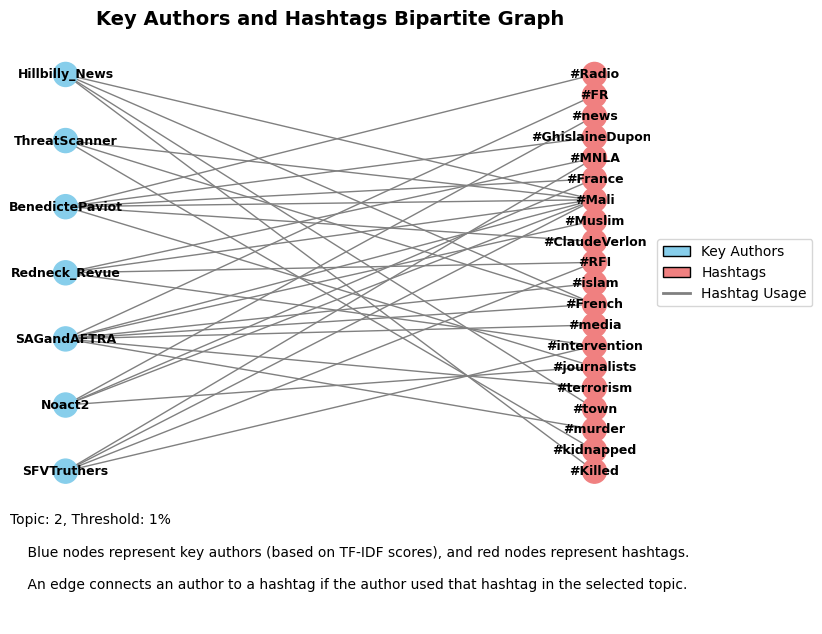

In [ ]:
top_nodes = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
pos = nx.bipartite_layout(G, top_nodes)
node_colors = [G.nodes[n]['color'] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=9, font_weight='bold', edge_color='gray')

plt.title(G.graph['title'], fontsize=14, fontweight='bold')

plt.text(0.0, -0.0, G.graph['explanation'], ha='left',va='top',transform=plt.gca().transAxes, fontsize=10,wrap=True)

legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Key Authors'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Hashtags'),
    Line2D([0], [0], color='gray', lw=2, label='Hashtag Usage')
]
plt.legend( handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.5)

plt.axis('off')
plt.show()

## Behavioral Similarity Graph
This Behavioral Similarity Graph illustrates key authors and the hashtags they used within a specific topic.
Blue nodes represent authors, red nodes represent hashtags, and edges indicate usage.

In [ ]:
from itertools import combinations

def build_author_similarity_graph(df, authors_tfidf_dict, topic_id, top_percent=1):
    """
    Builds a graph where nodes are key-authors and edges connect authors who used at least one common hashtag.
    Args:
        df (pd.DataFrame): DataFrame with 'author' (list), 'hashtags' (list), 'topic'.
        authors_tfidf_dict (dict): {topic: {author: tfidf_score}}.
        topic_id (int): Topic to filter by.
        top_percent (float): Threshold for selecting top authors.
    Returns:
        networkx.Graph
    """

    title = "Key Author Behavioral Similarity Graph"
    topic = topic_id_to_title[topic_id]
    explanation = f"""Topic_id: {topic_id}, Topic: {topic}
                      \nKey Authors' Threshold: {top_percent}%
                      \nNode lable: author's name, tf-idf score.
                      \nEdge width represents number of shared hashtags between authors"""
    G = nx.Graph(title = title, explanation=explanation,topic_id=topic_id, topic=topic, top_percent=top_percent)

    # Build author_hashtags_dict {author: set of hashtags}
    key_author_hashtags_dict = defaultdict(set)
    for _, row in df.iterrows():

        author = row['author']

        # Filters only relevant rows.
        if row['topic'] != topic_id or not is_key_author(authors_tfidf_dict, topic_id, author, top_percent):
            continue

        key_author_hashtags_dict[author].update(row['hashtags'])

    # Add authors nodes
    for author in key_author_hashtags_dict.keys():
        G.add_node(author, score=authors_tfidf_dict[topic_id][author] ,color='skyblue')

    # Add edges between authors who share at least one hashtag
    for a1, a2 in combinations(key_author_hashtags_dict.keys(), 2):
        shared_hashtags = key_author_hashtags_dict[a1] & key_author_hashtags_dict[a2]
        if shared_hashtags:
            G.add_edge(a1, a2, weight=len(shared_hashtags))

    return G

G = build_author_similarity_graph(df, authors_tfidf_dict, topic_id=2)

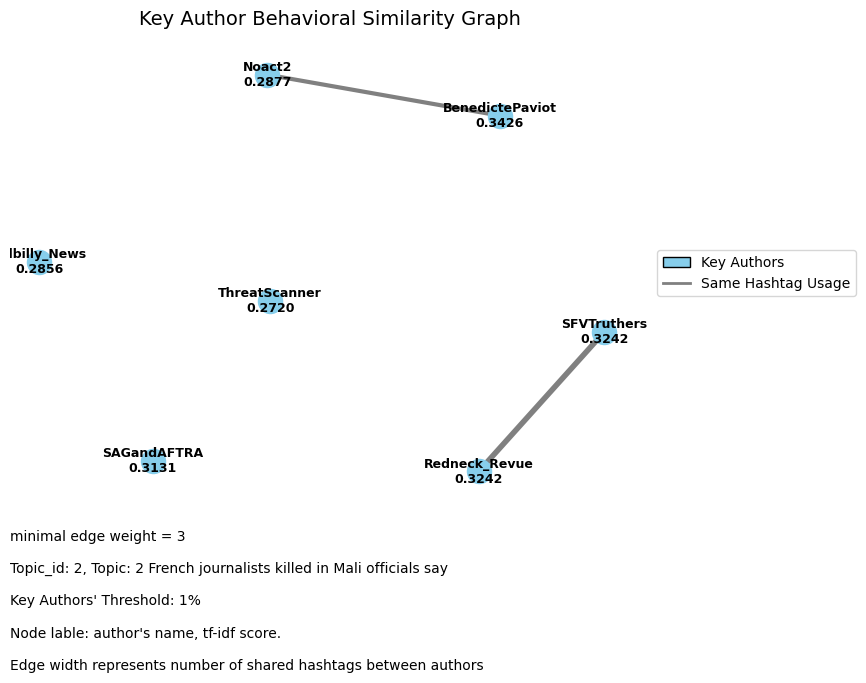

+---+-----------------+----------+---------------------------------------------------+-----------------+----------------------+-------------------------------------------------------------------------------------------+---------------------+
|   |     Authors     | Topic Id |                       Topic                       | Number of Posts | Average TF-IDF Score |                                     Hashtags (Counts)                                     | Topic (Frequencies) |
+---+-----------------+----------+---------------------------------------------------+-----------------+----------------------+-------------------------------------------------------------------------------------------+---------------------+
| 0 |   SFVTruthers   |    2     | 2 French journalists killed in Mali officials say |        1        |        0.3242        |                       #intervention(1), #Mali(1), #MNLA(1), #RFI(1)                       |        2(1)         |
| 1 |   SAGandAFTRA   |    2    

In [76]:
minimal_edge_weight = 3 # Filter by the weight = Number of sharder hastags.


filtered_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] >= minimal_edge_weight]
edge_weights = [G.edges[e]['weight'] for e in filtered_edges]

labels = {node: f"{node}\n{G.nodes[node]['score']:.4f}" for node in G.nodes()}

nx.draw_spring(G, with_labels=True, labels=labels, node_color='skyblue', font_size=9, font_weight='bold', edge_color='gray',edgelist = filtered_edges, width = edge_weights)
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Key Authors'),
    Line2D([0], [0], color='gray', lw=2, label='Same Hashtag Usage')
]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.5)
plt.title(G.graph["title"], fontsize=14)
plt.text(0.0, -0.0, f"\nminimal edge weight = {minimal_edge_weight}\n\n" + G.graph["explanation"]  , ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, wrap=True)
plt.axis('off')
plt.show()

summary_df = summarize_author_activity(df, author=G.nodes, topic_id = G.graph['topic_id'])
print(tabulate(summary_df, headers='keys', tablefmt='pretty'))

# Statistics

## List of Extracted Topics

In [95]:
topic_counts_df = df['topic'].value_counts().reset_index()
topic_counts_df.columns = ['topic', 'count']  # rename for clarity
topic_counts_df['title'] = topic_counts_df['topic'].apply(lambda x: topic_id_to_title[x])

print("Head of topic_counts_df:")
print(tabulate(topic_counts_df.head(), headers='keys', tablefmt='pretty'))

Head of topic_counts_df:
+---+-------+-------+-------------------------------------------------------------+
|   | topic | count |                            title                            |
+---+-------+-------+-------------------------------------------------------------+
| 0 |  123  | 2640  |     Canadians held without charge in Egypt headed home      |
| 1 |  924  | 2522  |       US ambassador denounces Gaza terrorist tunnels        |
| 2 |  142  | 2514  |       Congress lumbers while threatened default looms       |
| 3 |  297  | 2504  | Hawkish MKs call to rethink peace talks after Psagot attack |
| 4 |  107  | 2498  |                  Betrayals banks and Bibi                   |
+---+-------+-------+-------------------------------------------------------------+


## TF-IDF Stats per Entity & Topic

In [ ]:
def print_entity_score_stats(dict_item_score, topic_id, entity_type=""):
    """
    Prints statistics for a specific entity type in a given topic.
    Args:
        dict_item_score (dict) {topic: {entity: score}}
        topic_id (int): Topic identifier.
        entity_type (str): Entity type (e.g., 'hashtags', 'mentions').
    """
    scores = list(dict_item_score[topic_id].values())
    if not scores:
        print(f"No scores found for {entity_type}")
        return
    print(f"--- Stats for Topic Id: {topic_id} and Entity Type {entity_type} ---")
    print(f"Min: {np.min(scores):.4f}")
    print(f"Max: {np.max(scores):.4f}")
    print(f"Mean: {np.mean(scores):.4f}")
    print(f"Std: {np.std(scores):.4f}")
    print(f"Median: {np.median(scores):.4f}")

    sorted_entities_by_scores = (sorted(dict_item_score[topic_id].items(), key=lambda x: x[1], reverse=True))[:5]
    print(f"Top 5 {entity_type}:")
    for entity, score in sorted_entities_by_scores:
        print(f"\t \t {entity:<15} Score: {score:.4f}")
    print()


print_entity_score_stats(hashtags_tfidf_dict, topic_id=2, entity_type="Hashtags")
print_entity_score_stats(mention_tfidf_dict, topic_id=2, entity_type="Mentions")
print_entity_score_stats(authors_tfidf_dict, topic_id=2, entity_type="Authors")
# new entity dict's structure: {topic: {entity: tfidf_score}}
# old entity dict's structure: {(topic, entity): tfidf_score}

--- Stats for Topic Id: 2 and Entity Type Hashtags ---
Min: 0.0008
Max: 0.2073
Mean: 0.0155
Std: 0.0169
Median: 0.0131
Top 5 Hashtags:
	 	 #Mali           Score: 0.2073
	 	 #Uganda         Score: 0.0728
	 	 #RFI            Score: 0.0615
	 	 #French         Score: 0.0504
	 	 #journalists    Score: 0.0488

--- Stats for Topic Id: 2 and Entity Type Mentions ---
Min: 0.1316
Max: 0.4764
Mean: 0.2570
Std: 0.0903
Median: 0.2382
Top 5 Mentions:
	 	 @MalzZ036       Score: 0.4764
	 	 @Officials      Score: 0.4764
	 	 @FredianiITV    Score: 0.4764
	 	 @Fraudulent72   Score: 0.2382
	 	 @Ntaayisthename Score: 0.2382

--- Stats for Topic Id: 2 and Entity Type Authors ---
Min: 0.0000
Max: 0.3426
Mean: 0.0153
Std: 0.0489
Median: 0.0000
Top 5 Authors:
	 	 BenedictePaviot Score: 0.3426
	 	 SFVTruthers     Score: 0.3242
	 	 Redneck_Revue   Score: 0.3242
	 	 SAGandAFTRA     Score: 0.3131
	 	 Noact2          Score: 0.2877



## TF-IDF Scores Histogram

In [ ]:
def get_all_tfidf_scores(entity_tfidf_dict):
    """
    Collects all TF-IDF scores from a nested dict.
    Args:
        entity_tfidf_dict (dict): Nested dict of entity TF-IDF scores {topic: {entity: score}}.
    Returns:
        list: All TF-IDF scores from all entities in all topics.
    """
    all_tfidf_scores = []
    for entity_scores in entity_tfidf_dict.values():
        all_tfidf_scores.extend(entity_scores.values())
    return all_tfidf_scores

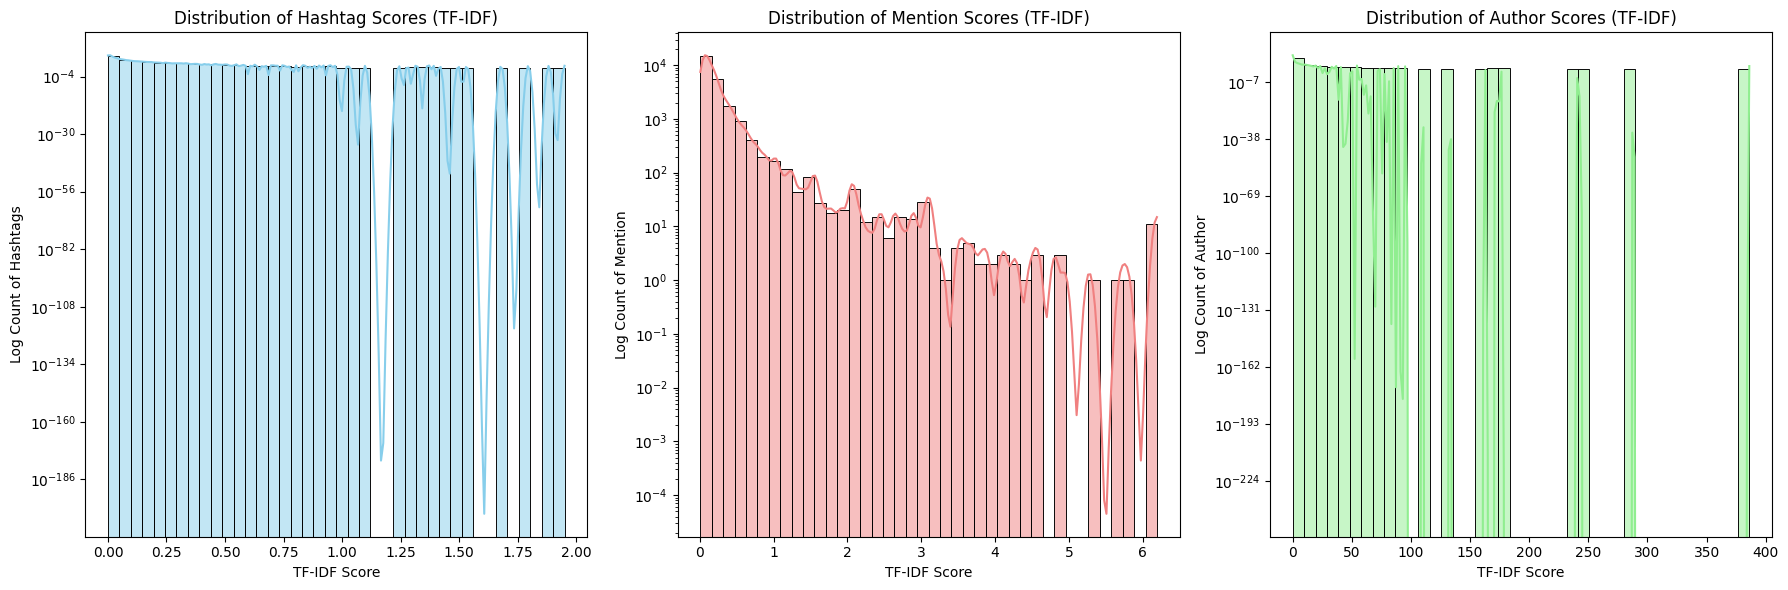

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Collecting Scores ---

all_hashtag_scores = get_all_tfidf_scores(hashtags_tfidf_dict)
all_mention_scores = get_all_tfidf_scores(mention_tfidf_dict)
all_author_scores = get_all_tfidf_scores(authors_tfidf_dict)

# --- Plotting the Histograms ---

plt.figure(figsize=(18, 6)) # Set the overall figure size

# Histogram for Hashtag Scores
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
if all_hashtag_scores:
    sns.histplot(all_hashtag_scores, kde=True, bins=40, color='skyblue')
    plt.title('Distribution of Hashtag Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Log Count of Hashtags') # Y-axis label changed to English
    plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Hashtag Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

# Histogram for Mention Scores
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
if all_mention_scores:
    sns.histplot(all_mention_scores, kde=True, bins=40, color='lightcoral')
    plt.title('Distribution of Mention Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Log Count of Mention') # Y-axis label changed to English
    plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Mention Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

# Histogram for Author Scores
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
if all_author_scores:
    sns.histplot(all_author_scores, kde=True, bins=40, color='lightgreen')
    plt.title('Distribution of Author Scores (TF-IDF)') # Title changed to English
    plt.xlabel('TF-IDF Score') # X-axis label changed to English
    plt.ylabel('Log Count of Author') # Y-axis label changed to English
    plt.yscale('log')
    # plt.xscale('log')
else:
    plt.text(0.5, 0.5, 'No Author Scores to display', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)

plt.tight_layout()
plt.show()

# Min Max Scale

In [ ]:
from collections import defaultdict

def min_max_normalize_by_topic(entity_tfidf_dict):
    """
    Normalize TF-IDF scores per topic using Min-Max normalization.
    Args:
        entity_tfidf_dict (dict): Nested dict {topic: {entity: score}}.
    Returns:
        dict: Nested dict {topic: {entity: normalized_score}}.
    """
    topic_to_stats = {}
    for topic, entity_scores in entity_tfidf_dict.items():
        scores = entity_scores.values()
        min_val = min(scores)
        max_val = max(scores)
        topic_to_stats[topic] = (min_val, max_val)

    norm_dict = defaultdict(lambda: defaultdict(float))
    for topic, entity_scores in entity_tfidf_dict.items():
        min_val, max_val = topic_to_stats[topic]
        for entity, score in entity_scores.items():
            if max_val - min_val == 0:
                norm_score = 0
            else:
                norm_score = (score - min_val) / (max_val - min_val)
            norm_dict[topic][entity] = norm_score

    return dict(norm_dict)

In [ ]:
from itertools import islice

def print_nested_dict_preview(nested_dict, num_topics=2, num_entities=2):
    """
    Print a preview of a nested .
    Args:
        nested_dict (dict): The nested dictionary to print, dict: {topic: {entity: score}}.
        num_topics (int): number of topics to show.
        num_entities (int or None): Max number of entities per topic to show (None = show all).
    """
    for topic, entity_scores in islice(nested_dict.items(), num_topics):
        print(f"Topic: {topic}")
        for entity, score in islice(entity_scores.items(), num_entities):
            print(f"  {entity}: {score}")
        print()  # Blank line between topics
    print("--- End ---")
    print()

In [ ]:
# Apply normalization to each entity type
norm_hashtag_scores = min_max_normalize_by_topic(hashtags_tfidf_dict)
norm_mention_scores = min_max_normalize_by_topic(mention_tfidf_dict)
norm_author_scores = min_max_normalize_by_topic(authors_tfidf_dict)


print("--- raw_hashtag_scores ---\n")
print_nested_dict_preview(hashtags_tfidf_dict)
print("--- norm_hashtag_scores ---\n")
print_nested_dict_preview(norm_hashtag_scores)

--- raw_hashtag_scores ---

Topic: 2
  #Uganda: 0.07282823658128308
  #News19: 0.013815719017426604

Topic: 770
  #Democratics: 0.008016265930001959
  #gop: 0.0019164106800505524

--- End ---

--- norm_hashtag_scores ---

Topic: 2
  #Uganda: 0.34860694173768036
  #News19: 0.06280166448947086

Topic: 770
  #Democratics: 0.0540495487123251
  #gop: 0.011707986187959579

--- End ---



In [ ]:
import pandas as pd

def show_top_entities_before_after_normalization(original_dict, normalized_dict, topic_id, top_n=10):
    """
    Print top-N entities for a specific topic before and after normalization.

    Args:
        nested_dict (dict): {topic: {entity: score}}.
        original_dict (dict): {topic: {entity: raw_tfidf_score}}
        normalized_dict (dict): {topic: {entity: normalized_tfidf_score}}
        topic_id (int or str): the topic to filter by
        top_n (int): number of top entities to display
    """
    # Filter entries for the given topic
    data = []
    for entity in original_dict[topic_id].keys():
            data.append({
                'Entity': entity,
                'Raw TF-IDF': original_dict[topic_id][entity],
                'Normalized TF-IDF': normalized_dict[topic_id][entity]
            })

    df = pd.DataFrame(data)

    # Sort and select top N by raw TF-IDF
    top_raw = df.sort_values(by='Raw TF-IDF', ascending=False).head(top_n)
    print(f"\nTop {top_n} entities for topic {topic_id} — by **Raw TF-IDF**:\n")
    print(top_raw.to_string(index=False))

    # Sort and select top N by normalized TF-IDF
    top_norm = df.sort_values(by='Normalized TF-IDF', ascending=False).head(top_n)
    print(f"\nTop {top_n} entities for topic {topic_id} — by **Normalized TF-IDF**:\n")
    print(top_norm.to_string(index=False))


show_top_entities_before_after_normalization(
    hashtags_tfidf_dict,
    norm_hashtag_scores,
    topic_id=2,
    top_n=10
)


Top 10 entities for topic 2 — by **Raw TF-IDF**:

      Entity  Raw TF-IDF  Normalized TF-IDF
       #Mali    0.207327           1.000000
     #Uganda    0.072828           0.348607
        #RFI    0.061498           0.293734
     #French    0.050392           0.239948
#journalists    0.048810           0.232283
       #COYI    0.044259           0.210242
        #BPL    0.044259           0.210242
 #journalist    0.044137           0.209653
          #2    0.037010           0.175132
      #Marea    0.034611           0.163514

Top 10 entities for topic 2 — by **Normalized TF-IDF**:

      Entity  Raw TF-IDF  Normalized TF-IDF
       #Mali    0.207327           1.000000
     #Uganda    0.072828           0.348607
        #RFI    0.061498           0.293734
     #French    0.050392           0.239948
#journalists    0.048810           0.232283
       #COYI    0.044259           0.210242
        #BPL    0.044259           0.210242
 #journalist    0.044137           0.209653
          #

Normalize the scores to ensure fair comparison across different entity types.

In [ ]:
def compute_mean_score(scores):
    return np.mean(scores) if scores else 0

df['mean_hashtag_score'] = df['hashtag_scores'].apply(compute_mean_score)
# df['mean_url_score'] = df['url_scores'].apply(compute_mean_score)
df['mean_mention_score'] = df['mention_scores'].apply(compute_mean_score)
df['mean_author_score'] = df['author_score'].apply(compute_mean_score)

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score,mean_hashtag_score,mean_mention_score,mean_author_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828,0.072828,0.072828,0,0.072828
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000,0.000000,0.000000,0,0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000,0.000000,0.000000,0,0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000,0.051999,0.000000,0,0.051999
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000,0.000000,0.000000,0,0.000000


In [ ]:
df['min_max_post_score'] = (
    df['mean_hashtag_score'] +
    # df['mean_url_score'] +
    df['mean_mention_score'] +
    df['mean_author_score']
)

df.head()

,c_post_id,title,content,date,topic,author,hashtags,user_mentions,hashtag_scores,mention_scores,post_topic_tfidf,author_score,mean_hashtag_score,mean_mention_score,mean_author_score,min_max_post_score
0,00ef3764-f159-3166-b3e3-8b1147aed472,2 French journalists killed in Mali officials say,"RT @ hrw: # Uganda: 2 newspapers, 2 radio stat...",2013-05-21 10:27:02,2,karmel80,[#Uganda],[],[0.07282823658128308],[],0.072828,0.072828,0.072828,0,0.072828,0.145656
1,01062bf4-590c-306d-b194-809d4c12b8b0,2 French journalists killed in Mali officials say,Officials: 2 French journalists killed in Mali...,2013-11-03 00:49:32,2,MynameRillo,[],[],[],[],0.000000,0.000000,0.000000,0,0.000000,0.000000
2,0153a78a-de08-35ea-b9e2-d717e9b34ae0,2 French journalists killed in Mali officials say,DR (Danish Radio) tells the story of state-own...,2013-01-13 22:31:18,2,JakobDrud,[],[],[],[],0.000000,0.000000,0.000000,0,0.000000,0.000000
3,02803736-bdab-3ff9-b5f6-933492f3b732,2 French journalists killed in Mali officials say,"Newspapers: Journalist / Regional Journalist, ...",2013-06-26 20:42:50,2,uk_radio,[],[],[],[],0.000000,0.051999,0.000000,0,0.051999,0.051999
4,02bae70c-0075-3954-8fe0-24f62d068286,2 French journalists killed in Mali officials say,[WOI] Officials: 2 French journalists killed i...,2013-11-02 21:33:56,2,DesMoinesNews,[],[],[],[],0.000000,0.000000,0.000000,0,0.000000,0.000000


In [ ]:
sorted_posts = df.sort_values(by=['topic', 'min_max_post_score'], ascending=[True, False])

In [ ]:
num_topics = sorted_posts['topic'].unique()

for topic in num_topics:
    print(f"\nTop 5 Posts for Topic {topic}:")
    top_posts = sorted_posts[sorted_posts['topic'] == topic].head(5)
    for idx, row in top_posts.iterrows():
        print(f"Post ID: {row['c_post_id']}, Key Post Score: {row['min_max_post_score']:.4f}")
        print(f"Content: {row['content']}")
        print(f"Hashtags: {row['hashtags']}")
        # print(f"URL Scores: {row['url_scores']}")
        print(f"Mention Scores: {row['mention_scores']}")
        print(f"Author Score: {row['author_score']}")
        print()


Streaming output truncated to the last 5000 lines.
Author Score: 49.17804449204673

Post ID: 1f569707-13b8-37f3-a337-4b656a1035f2, Key Post Score: 49.3298
Content: Israel: Second # F35 Deal Is in the Cards # JSF # USAF # USN # USMC # DoD # military # milblog # tcot http://ow.ly/bwXl0
Hashtags: ['#F35', '#JSF', '#USAF', '#USN', '#USMC', '#DoD', '#military', '#milblog', '#tcot']
Mention Scores: []
Author Score: 49.17804449204673


Top 5 Posts for Topic 842:
Post ID: 941297a5-7da4-3d5a-8d2d-e11bdcab9d37, Key Post Score: 5.9208
Content: # ATV # Parts #4: Kenda Executioner ATV Tire 27x12-12 ARCTIC CAT BOMBARDIER CAN-AM HONDA JOHN... http://amzn.to/MeIjSO # BestBuy # Motorcycle
Hashtags: ['#ATV', '#Parts', '#4', '#BestBuy', '#Motorcycle']
Mention Scores: []
Author Score: 5.8217870024726235

Post ID: c704db45-2429-3014-86fd-0c8e938916f6, Key Post Score: 5.9208
Content: # ATV # Parts #4: Kenda Executioner ATV Tire 27x10-12 ARCTIC CAT BOMBARDIER CAN-AM HONDA JOHN... http://amzn.to/10rxDtJ # Bes